# TP 3 : Embeddings

<img src="./tp3-header.png" width="1000">

On va s'appuyer sur le corpus collecté par <span class="badge badge-secondary">(Panckhurst et al., 2016)</span> qui rassemble 88,000 sms collectés dans la région de Montpellier. Le corpus a été dé-identifié (en particulier, les noms sont remplacés par [_forename_]). Pour chaque sms, on a identifié les Emojis dans le texte.

Il y avait beaucoup de type d'Emojis. Dans le TP, ils ont été simplifiés selon le tableau suivant. Tous les Emojis de la colonne `Emoji list` ont été remplacé par l'emoji de la colonne `Generic`. Dans le TP les Emojis n'apparaissent pas dans le texte du sms car on cherche à les prédire.


| Generic Emoji  | Emoji list                                                         |
|:--------------:|:------------------------------------------------------------------:|
| 😃             | '=P', ':)', ':P', '=)', ':p', ':d', ':-)', '=D', ':D', '^^'        |
| 😲             | ':O', 'o_o', ':o', ':&'                                            | 
| 😔             | '"-.-'''", '<_>', '-_-', "--'", "-.-'", '-.-', "-.-''", "-\_-'"    | 
| 😠             | ':/', ':-/', ':-(', ':(', ':-<'                                    | 
| 😆             | '>.<', '¤.¤', '<>','><', '*.*', 'xd', 'XD', 'xD', 'x)',';)', ';-)' | 
| 😍             | '</3', '<3'                                                        | 
 

Finalement pour le TP, on a filtré le jeu de données pour ne conserver que les sms contenant qu'un seul Emoji. On a par ailleurs <i>down samplé</i> les classes majoritaires pour limiter le déséquilibre du jeu de données. En effet les sms avec un smiley 😃 était largement sur-représentés.

<b>L'objet du TP est de prédire l'émoji associé à chaque message. Pour cela on vectorisera le texte en utilisant les méthodes d'embeddings.</b>

<span class="badge badge-secondary">(Panckhurst et al., 2016)</span> Panckhurst, Rachel, et al. "88milSMS. A corpus of authentic text messages in French." Banque de corpus CoMeRe. Chanier T.(éd)-Ortolang: Nancy (2016).

In [1]:
# Execute if running in Colab

# !pip install -q scikit-learn==0.23.2 matplotlib==3.1.3 pandas==1.1.3 gensim==3.8.1 torch==1.6.0 torchvision==0.7.0


In [54]:
from gensim.models import KeyedVectors

from collections import Counter
import numpy as np
import pandas as pd
import re

import os, sys
sys.path.append(os.path.abspath('../../m2-data-sciences/src'))

import matplotlib.pyplot as plt

# set font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'

# set the style of the axes and the text color
plt.rcParams['axes.edgecolor']='#333F4B'
plt.rcParams['axes.linewidth']=0.8
plt.rcParams['xtick.color']='#333F4B'
plt.rcParams['ytick.color']='#333F4B'
plt.rcParams['text.color']='#333F4B'

# IPython automatically reload all changed code
%load_ext autoreload
%autoreload 2

# Inline Figures with matplotlib
%matplotlib inline
%config InlineBackend.figure_format='retina'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


On va utiliser les embeddings déjà entrainé que nous avons manipulé au cours précédent. Pour limiter la taille du fichier d'embeddings, on a sauvegardé que les `10,000` mots les plus fréquents. <b>Vous devez récupérer le fichier d'embeddings directement sur le Moodle.</b>

In [2]:
w2v_model = KeyedVectors.load_word2vec_format("oscar.fr.300.10k.model")
w2v_model.init_sims(replace=True)

In [3]:
len(w2v_model.vocab)

10000

In [4]:
# On crée un array avec les 10,000 premiers mots et on crée le dictionaire de vocabulaire

word_count = {k: w2v_model.vocab[k].count for k in w2v_model.vocab}
word_count = Counter(word_count)
word_count.most_common(10)

idx2w = {i: w for (i, (w, f)) in enumerate(word_count.most_common(10000))}
w2idx = {w: i for (i, (w, f)) in enumerate(word_count.most_common(10000))}


embeddings_vectors = [w2v_model[w] for (w, f) in word_count.most_common(10000)]
word2vec_embeddings = np.vstack(embeddings_vectors)

In [5]:
word2vec_embeddings.shape

(10000, 300)

In [6]:
w2idx['Oh']

3664

In [7]:
word2vec_embeddings[3664][:10]

array([-0.0133751 , -0.16667102,  0.00242356, -0.01808304, -0.01267814,
        0.05172095,  0.04931232, -0.06592007, -0.05656065,  0.03720263],
      dtype=float32)

In [8]:
w2v_model['Oh'][:10]

array([-0.0133751 , -0.16667102,  0.00242356, -0.01808304, -0.01267814,
        0.05172095,  0.04931232, -0.06592007, -0.05656065,  0.03720263],
      dtype=float32)

<b>Vous devez récupérer le jeu de données directement sur le Moodle.</b>

In [9]:
dataset = pd.read_csv('emojis.csv')

In [10]:
dataset.head()

,Unnamed: 0,Unnamed: 0.1,sms,happy,joke,astonished,angry,bored,heart,filter,tokens
0,1,4,Oh trop mignon mon bbé jsuis au travaiiiil la,False,False,False,False,False,True,True,"['Oh', 'trop', 'mignon', 'mon', 'bbé', 'jsuis'..."
1,3,6,Mon cher et tendre filleul... Je m'engage a et...,False,False,False,False,False,True,True,"['Mon', 'cher', 'et', 'tendre', 'filleul', '....."
2,4,7,Ohhhhhh non ! Héhé j'te texto en mode scred mo...,False,False,False,False,False,True,True,"['Ohhhhhh', 'non', '!', 'Héhé', ""j'"", 'te', 't..."
3,6,11,Non chez mon arriere grand mere juste a coté d...,False,True,False,False,False,False,True,"['Non', 'chez', 'mon', 'arriere', 'grand', 'me..."
4,7,14,Demain jai deux heures de pause si tu veux on ...,False,True,False,False,False,False,True,"['Demain', 'jai', 'deux', 'heures', 'de', 'pau..."


In [11]:
dataset.loc[3, 'sms']

'Non chez mon arriere grand mere juste a coté de chez mes grands parents'

In [12]:
class_names = ['happy', 'joke', 'astonished', 'angry', 'bored', 'heart']

In [13]:
dataset.shape

(6387, 11)

On va utiliser la même fonction de tokenization qui a été utilisée pour entrainer les embeddings.

In [14]:
token_pattern = re.compile(r"(\->|(?::\)|:-\)|:\(|:-\(|;\);-\)|:-O|8-|:P|:D|:\||:S|:\$|:@|8o\||\+o\(|\(H\)|\(C\)|\(\?\))|(?:[\d.,]+)|([^\s\w0-9])\2*|(?:[\w0-9\.]+['’]?)(?<!\.))")

def tokenize(text):
    tokens = [groups[0] for groups in re.findall(token_pattern, str(text))]
    tokens = [t.strip() for t in tokens]
    return tokens

In [15]:
dataset['tokens'] = dataset['sms'].apply(tokenize)

In [16]:
dataset.head()

,Unnamed: 0,Unnamed: 0.1,sms,happy,joke,astonished,angry,bored,heart,filter,tokens
0,1,4,Oh trop mignon mon bbé jsuis au travaiiiil la,False,False,False,False,False,True,True,"[Oh, trop, mignon, mon, bbé, jsuis, au, travai..."
1,3,6,Mon cher et tendre filleul... Je m'engage a et...,False,False,False,False,False,True,True,"[Mon, cher, et, tendre, filleul, ..., Je, m', ..."
2,4,7,Ohhhhhh non ! Héhé j'te texto en mode scred mo...,False,False,False,False,False,True,True,"[Ohhhhhh, non, !, Héhé, j', te, texto, en, mod..."
3,6,11,Non chez mon arriere grand mere juste a coté d...,False,True,False,False,False,False,True,"[Non, chez, mon, arriere, grand, mere, juste, ..."
4,7,14,Demain jai deux heures de pause si tu veux on ...,False,True,False,False,False,False,True,"[Demain, jai, deux, heures, de, pause, si, tu,..."


### Exploration de données

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Observer la distribution des classes.</p>
</div>    

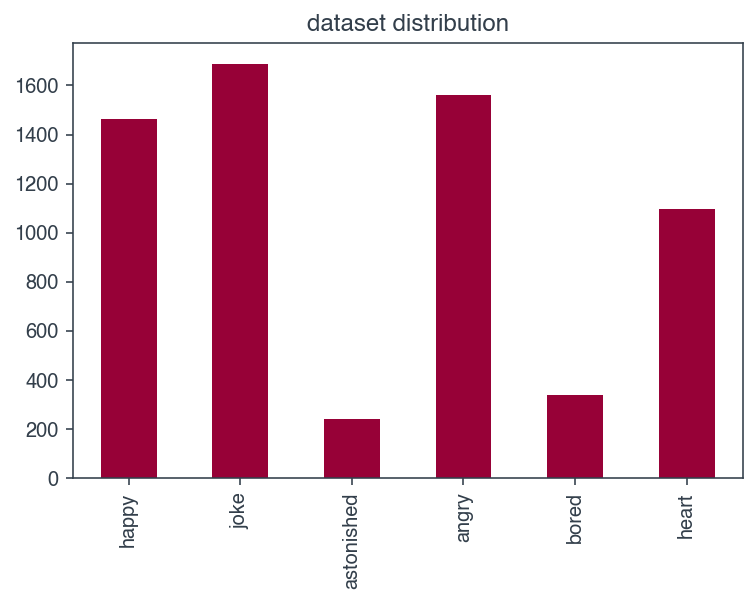

In [126]:
dataset[["happy", "joke", "astonished", "angry", "bored", "heart"]].sum().plot.bar(color='#970137', 
                                                                                   title="dataset distribution");

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Evaluer la proportion de tokens qui sont hors du vocabulaire des embeddings.</p>
</div>    

In [19]:
# %load solutions/unk.py

tokens_not_in_voc = []

for sms in dataset['tokens']:
    for t in sms:
        tokens_not_in_voc.append(t not in w2idx)

print("On a {:.2f}% des tokens hors du vocab".format(sum(tokens_not_in_voc) / len(tokens_not_in_voc) * 100))

On a 13.40% des tokens hors du vocab


### Vectorization

Les embeddings de mots permettent de représenter chaque <i>token</i> par un vecteur. Pour obtenir un vecteur qui représente le sms, on va agréger les différents mots du texte. On considérera plusieurs fonctions d'agrégation : la somme, la moyenne, me maximum ou le minimum.

En pratique nous verrons dans le dernier cours d'ouverture qu'il existe des méthodes plus évoluées pour composer les mots de la phrase. Néanmoins une simple fonction d'agrégation nous donnera déjà une bonne <i>baseline</i>.

<img src="./model.png" width="500">

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Ecrire une fonction qui permet de vectoriser un sms.</p>
</div>    

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
dataset['tokens'][0]

['Oh', 'trop', 'mignon', 'mon', 'bbé', 'jsuis', 'au', 'travaiiiil', 'la']

In [22]:
np.zeros_like(embeddings_vectors[0]).shape

(300,)

In [60]:
# %load solutions/vectorize_1.py

def vectorize(tokens, agg_method='mean'):
    
    token_embeddings_arr = np.array([w2v_model[t] for t in tokens if t in w2v_model.vocab])
    
    if not len(token_embeddings_arr):
        return np.zeros_like(w2v_model['roi'])
    
    # Agréger les représentations de chaque token.
    # Le vecteur de sortie doit être de taille (300, )
    
    if agg_method == 'mean':
        sentence_embedding = np.mean(token_embeddings_arr, axis=0)
    elif agg_method == 'max':
        sentence_embedding = np.max(token_embeddings_arr, axis=0)
    elif agg_method == 'sum':
        sentence_embedding = np.sum(token_embeddings_arr, axis=0)
    
    return sentence_embedding
    

In [61]:
vectorize(dataset['tokens'][0], agg_method='max')

array([ 0.00527477,  0.00692021,  0.00242356,  0.06154046,  0.13295795,
        0.06361634,  0.08570134,  0.07414384, -0.00225028,  0.08212721,
        0.04973175,  0.03402816,  0.06700727,  0.02743915,  0.07400591,
        0.05501981,  0.11267069,  0.0881431 ,  0.05800019,  0.09302516,
        0.00409879,  0.02342506, -0.00573595,  0.0402468 ,  0.054419  ,
        0.08634509,  0.05533285,  0.07128762,  0.19060998,  0.02699462,
        0.00081452,  0.09166943,  0.04762873,  0.08533753,  0.03304539,
        0.09167273,  0.04074982,  0.06496961,  0.04717816,  0.06464085,
        0.07810198,  0.11930461,  0.10063915,  0.04590213,  0.1329642 ,
        0.06927311,  0.12643115,  0.02072367,  0.05237858,  0.07072788,
        0.03413792,  0.03463707,  0.00823655,  0.06633823,  0.07935217,
        0.04817078,  0.05091089,  0.05601389,  0.03564481,  0.02593034,
        0.01066518,  0.05512953,  0.07356762,  0.09573206,  0.10821631,
        0.03146662,  0.07366633, -0.01329054,  0.07214772,  0.14

On voudrait attribuer un poids moins important aux embeddings des mots moins caractéristiques. Pour ça, on voudrait pondérer la contribution des vecteurs de chaque mot en fonction de leur score TF-IDF.

<img src="./model-tfidf.png" width="700">

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Uiliser la pondération TF-IDF pour pondérer chacun des vecteurs</p>
</div>    

In [62]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x,
                                   lowercase=False)

tfidf_vectorizer.fit(dataset['tokens'])

w2idx_tfidf = {w: idx for (idx, w) in enumerate(tfidf_vectorizer.get_feature_names())}
idx_tfidf2w = {idx: w for (idx, w) in enumerate(tfidf_vectorizer.get_feature_names())}

/Users/antoine/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_extraction/text.py:484: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"


In [63]:
w2idx_tfidf['Oh']

1230

In [64]:
expl_1_tfidf = tfidf_vectorizer.transform([dataset['tokens'][0]]).todense().transpose()
print(expl_1_tfidf.shape)

(10492, 1)


In [65]:
w2idx_tfidf['Oh']

1230

In [66]:
expl_1_tfidf[1230, 0]

0.2888766247464332

In [67]:
for t in dataset['tokens'][0]:
    print(t, expl_1_tfidf[w2idx_tfidf[t], 0])

Oh 0.2888766247464332
trop 0.22009470142004525
mignon 0.39228804412650337
mon 0.20163143305757703
bbé 0.4862393558550892
jsuis 0.3283377140100523
au 0.21107136353898548
travaiiiil 0.508995935937675
la 0.1603157035024473


In [70]:
# %load solutions/vectorize_2.py

def vectorize(tokens, agg_method='mean', tfidf_vectorizer=None):
    
    token_embeddings_arr = np.array([w2v_model[t] for t in tokens if t in w2v_model.vocab])
    
    if not len(token_embeddings_arr):
        return np.zeros_like(w2v_model['roi'])
    
    # Agréger les représentations de chaque token.
    # Le vecteur de sortie doit être de taille (300, )
    
    if agg_method == 'mean':
        sentence_embedding = np.mean(token_embeddings_arr, axis=0)
    elif agg_method == 'max':
        sentence_embedding = np.max(token_embeddings_arr, axis=0)
    elif agg_method == 'sum':
        sentence_embedding = np.sum(token_embeddings_arr, axis=0)
    elif agg_method == 'tfidf':
        tf_idf_w = tfidf_vectorizer.transform([tokens]).todense().transpose()
        tf_idf_w = np.squeeze([tf_idf_w[w2idx_tfidf[t]] for t in tokens if t in w2v_model.vocab])
        sentence_embedding =  np.average(vectors, weights=tf_idf_w, axis=0)
    return sentence_embedding

In [71]:
X = [vectorize(sms) for sms in dataset['tokens']]
X = np.array(X)
print(X.shape)

(6387, 300)


On va intégrer la fonction `vectorize` dans un module compatible avec les fonctions de `sklearn`.

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Intégrer votre fonction de vectorization dans la classe Vectorizer ci-dessous. Vous devez simoplement la copier/coller en replaçant tfidf_vectorizer par self.tfidf_vectorizer car c'est maintenant un attribut de la class.</p>
</div>    

In [72]:
# 6 choses à faire pour l'excercice sur la class Vectorizer :
# copier votre fonction vectorize dans la class
# ajouter l'argument self dans la fonction vectorize
# supprimer l'argument tfidf_vectorizer de la fonction vectorize
# remplacer toutes les occurences de agg_method par self.agg_method dans la fonction vectorize
# supprimer l'argument agg_method de la fonction vectorize
# remplacer toutes les occurences de w2idx_tfidf par self.w2idx_tfidf dans la fonction vectorize

In [91]:
# %load solutions/vectorizer.py

class Vectorizer(BaseEstimator, TransformerMixin):

    def __init__(self, agg_method='mean', normalize=False):
        self.agg_method = agg_method
        self.normalize = normalize
        self.tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x,
                                                lowercase=False,
                                                token_pattern=None)

    def vectorize(self, tokens):

        vectors = np.array([w2v_model[t] for t in tokens if t in w2v_model.vocab])

        if len(vectors) == 0:
            sentence_embedding = np.zeros_like(w2v_model['roi'])
        elif len(vectors) == 1:
            sentence_embedding = np.squeeze(vectors)
        elif len(vectors) > 1:
            if self.agg_method == 'mean':
                sentence_embedding = np.mean(vectors, axis=0)
            elif self.agg_method == 'max':
                sentence_embedding = np.max(vectors, axis=0)
            elif self.agg_method == 'sum':
                sentence_embedding = np.sum(vectors, axis=0)
            elif self.agg_method == 'tfidf':
                tf_idf_w = self.tfidf_vectorizer.transform([tokens]).todense().transpose()
                tf_idf_w = np.squeeze([tf_idf_w[self.w2idx_tfidf.get(t, 0)] for t in tokens if t in w2v_model.vocab])
                sentence_embedding = np.average(vectors, weights=tf_idf_w, axis=0)

        return sentence_embedding

    def _vectorize(self, tokens):
        return vectorize(tokens)

    def fit(self, X, y=None):
        self.tfidf_vectorizer.fit(X['tokens'])
        self.w2idx_tfidf = {w: idx for (idx, w) in enumerate(self.tfidf_vectorizer.get_feature_names())}
        self.idx_tfidf2w = {idx: w for (idx, w) in enumerate(self.tfidf_vectorizer.get_feature_names())}
        return self

    def transform(self, X, y=None, eps=1e-12):
        X = [self.vectorize(t) for t in X['tokens']]
        X = np.array(X)

        if self.normalize:
            X = X / np.linalg.norm(X + eps, axis=1, keepdims=True)
        return X

In [75]:
vectorizer = Vectorizer(agg_method='tfidf', normalize=True)

In [76]:
X = vectorizer.fit_transform(dataset)

In [77]:
X.shape

(6387, 300)

### Classification

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, roc_auc_score

On compare deux algorithmes de classification :  Une régression logistique et un SVM ou l'on pénalise les classes majoritaires.

In [79]:
X_train, X_test = train_test_split(
    dataset, test_size=0.33, random_state=42)

y_train = X_train[['happy', 'joke', 'astonished', 'angry', 'bored', 'heart']].astype(int).values
y_train = [x.tolist().index(1) for x in y_train]

y_test = X_test[['happy', 'joke', 'astonished', 'angry', 'bored', 'heart']].astype(int).values
y_test = [x.tolist().index(1) for x in y_test]

In [80]:
len(y_train)

4279

In [81]:
X_train.shape

(4279, 11)

In [82]:
LogReg_pipeline = Pipeline([
    ('vect', Vectorizer('tfidf')),
    ('clf', OneVsRestClassifier(LogisticRegression(solver='sag'))),
])


# Training logistic regression model on train data
LogReg_pipeline.fit(X_train, y_train)

# Infering data on test set
prediction_LogReg = LogReg_pipeline.predict(X_test)

In [83]:
SVC_pipeline = Pipeline([
    ('vect', Vectorizer('tfidf')),
    ('clf', OneVsRestClassifier(SVC(kernel='linear', 
                                    class_weight='balanced', # penalize
                                    probability=True), n_jobs=-1))
])


SVC_pipeline.fit(X_train, y_train)
prediction_SVC = SVC_pipeline.predict(X_test)

### Evaluation

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from plots import plot_confusion_matrix

Test accuracy is 0.325426944971537
Test ROC socre is 0.684440035931435
Confusion matrix, without normalization


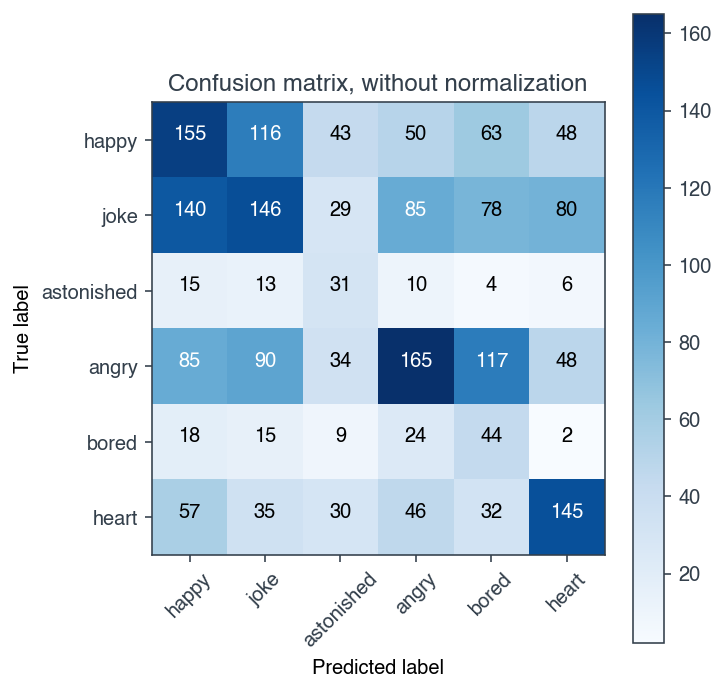

In [85]:
print('Test accuracy is {}'.format(accuracy_score(y_test, prediction_SVC)))
print('Test ROC socre is {}'.format(roc_auc_score(np.eye(np.max(y_test) + 1)[y_test],
                                                  SVC_pipeline.predict_proba(X_test), 
                                                  multi_class='ovo')))

plot_confusion_matrix(confusion_matrix(y_test, prediction_SVC), 
                      classes=class_names, 
                      title='Confusion matrix, without normalization')

Test accuracy is 0.3733396584440228
Test ROC socre is 0.6767339867507226
Confusion matrix, without normalization


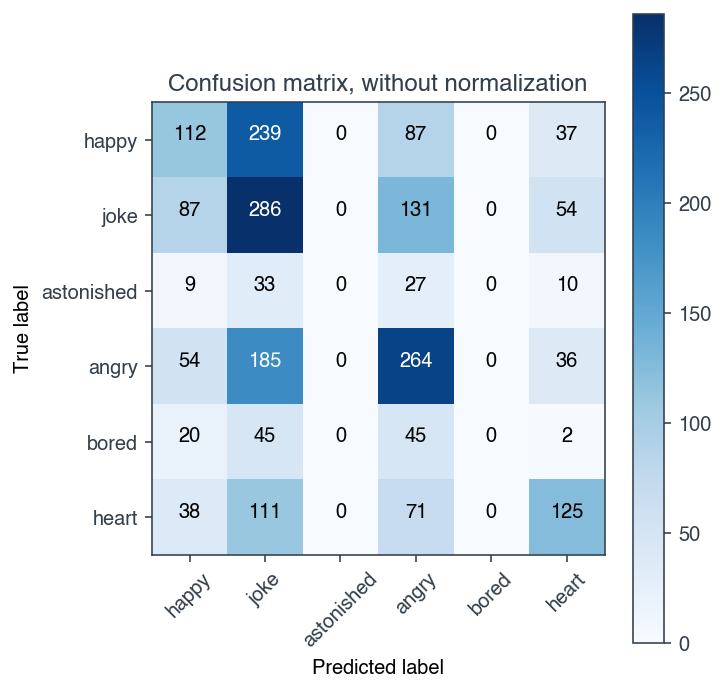

In [86]:
print('Test accuracy is {}'.format(accuracy_score(y_test, prediction_LogReg)))
print('Test ROC socre is {}'.format(roc_auc_score(np.eye(np.max(y_test) + 1)[y_test],
                                                  LogReg_pipeline.predict_proba(X_test), 
                                                  multi_class='ovo')))

plot_confusion_matrix(confusion_matrix(y_test, prediction_LogReg), 
                      classes=class_names, 
                      title='Confusion matrix, without normalization')

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Quelle mesure de performance vous semble le plus adaptée pour ce cas d'usage ?</p>
</div>    

La mesure de performance dépend évidemment du contexte d'évaluation du cas d'usage. Par exemple, si l'on est dans un cas de classification binaire ou l'on cherche à distinguer des spams d'emails normaux, les spams représenteront peut être 5% du jeu de données. Un algorithme qui prédirait toujours "not spam" aurait une précision de 95%, ce qui est évidemment inutile.

Dans notre cas, le jeu de données est légèrement déséquilibré. Quand on observe les résultats précédent, la régression logistique obtient une meilleure précision (37,3%) que le SVM (32,5%). Mais les matrices de confusion révèlent que pour la régression logistique, les classes minoritaires (astonished et bored) ne sont jamais prédite. Finalement la mesure ROC traduit mieux la capacité des méthodes à séparer les classes puisqu'elle est meilleure pour le SVM (0.684) que pour la régression logistique (0.677). Dans notre cas d'usage, la mesure ROC semble ainsi plus adaptée.

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Comparer les résultats obtenus avec les deux algorithmes de classifications</p>
</div>    

Comme on l'a mentionné précédemment, la régression logistique semble prioriser les classes majoritaires pour obtenir une meilleure précision globale. Cette dernière est beaucoup plus performante que le SVM pour prédire les classes "happy" ou "joke". Dans le SVM, on a appliqué un pénalité selon la distribution du jeu de données et ainsi on prédit les classes minoritaires. Chacune des classes indépendamment semble mieux modélisée et on voit ressortir la diagonale qui caractérise ce comportement.

Quand on observe le carré 2x2 dans le coin supérieur gauche de la matrice de confusion, on constate que les deux modèles semblent avoir du mal à distinguer les deux classes "happy" et "joke". Ces humeurs sont sans doutes trop proches et difficiles à distinguer.

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Comparer les différentes méthodes d'agrégation proposées. (Mean, Max, Sum, Moyenne pondérée par le TF-IDF)</p>
</div>    

In [92]:
test_svc = {'acc': {}, 'roc': {}}
test_logreg = {'acc': {}, 'roc': {}}

for agg_method in ['mean', 'max', 'sum', 'tfidf']:
    print('Computing agg method: {}'.format(agg_method))
    LogReg_pipeline = Pipeline([
        ('vect', Vectorizer(agg_method)),
        ('clf', OneVsRestClassifier(LogisticRegression(solver='sag'))),])

    SVC_pipeline = Pipeline([
        ('vect', Vectorizer(agg_method)),
        ('clf', OneVsRestClassifier(SVC(kernel='linear', 
                                        class_weight='balanced', # penalize
                                        probability=True), n_jobs=-1))])

    SVC_pipeline.fit(X_train, y_train)
    prediction_SVC = SVC_pipeline.predict(X_test)
    
    LogReg_pipeline.fit(X_train, y_train)
    prediction_LogReg = LogReg_pipeline.predict(X_test)
    
    test_svc['acc'][agg_method] = accuracy_score(y_test, prediction_SVC)
    test_svc['roc'][agg_method] = roc_auc_score(np.eye(np.max(y_test) + 1)[y_test],
                                                SVC_pipeline.predict_proba(X_test), 
                                                multi_class='ovo')
    
    test_logreg['acc'][agg_method] = accuracy_score(y_test, prediction_LogReg)
    test_logreg['roc'][agg_method] = roc_auc_score(np.eye(np.max(y_test) + 1)[y_test],
                                                   LogReg_pipeline.predict_proba(X_test), 
                                                   multi_class='ovo')
    
    
    print('Test accuracy for SVC with agg method {} is {}'.format(agg_method, test_svc['acc'][agg_method]))
    print('Test ROC score for ROC with agg method {} is {}'.format(agg_method, test_svc['roc'][agg_method]))

Computing agg method: mean
Test accuracy for SVC with agg method mean is 0.33064516129032256
Test ROC score for ROC with agg method mean is 0.6858614254176296
Computing agg method: max
Test accuracy for SVC with agg method max is 0.2998102466793169
Test ROC score for ROC with agg method max is 0.656631379711922
Computing agg method: sum


/Users/antoine/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:329: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/Users/antoine/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:329: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/Users/antoine/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:329: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/Users/antoine/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:329: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/Users/antoine/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_mode

Test accuracy for SVC with agg method sum is 0.33206831119544594
Test ROC score for ROC with agg method sum is 0.6849945789992137
Computing agg method: tfidf
Test accuracy for SVC with agg method tfidf is 0.325426944971537
Test ROC score for ROC with agg method tfidf is 0.6845961186597794


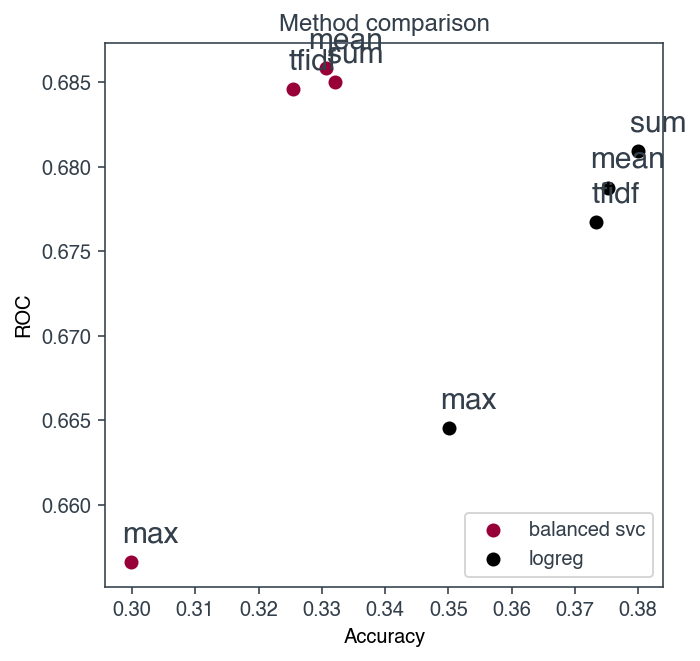

In [135]:
x_svc = [v for (k, v)in test_svc['acc'].items()]
y_svc = [v for (k, v)in test_svc['roc'].items()]

x_logreg = [v for (k, v)in test_logreg['acc'].items()]
y_logreg = [v for (k, v)in test_logreg['roc'].items()]

labels = ['svc', 'svc', 'svc', 'svc', 'logreg', 'logreg', 'logreg', 'logreg']
colors = ['#970137', '#970137', '#970137', '#970137', 'black', 'black', 'black', 'black']

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(x_svc, y_svc, color='#970137', label='balanced svc')
for i, agg in enumerate(['mean', 'max', 'sum', 'tfidf']):
    label = "{}".format(agg) 
    plt.annotate(label, (x_svc[i], y_svc[i]), 
                 textcoords="offset points", xytext=(10,10), 
                 ha='center', rotation=0, fontsize=15, fontweight='black') 
    

ax.scatter(x_logreg, y_logreg, color='black', label='logreg')
for i, agg in enumerate(['mean', 'max', 'sum', 'tfidf']):
    label = "{}".format(agg) 
    plt.annotate(label, (x_logreg[i], y_logreg[i]), 
                 textcoords="offset points", xytext=(10,10), 
                 ha='center', rotation=0, fontsize=15, fontweight='black') 

ax.set_xlabel('Accuracy')
ax.set_ylabel('ROC')
ax.set_title('Method comparison')
ax.legend(loc=4)
plt.show();

On peut comparer les méthodes d'aggrégation et l'algorithme de classification en fonction de la mesure de précision ou ROC. Pour la mesure ROC, le SVC obtient les meilleures performances avec la moyenne. Pour la précision, on obtient les meilleures précisions avec la régression logistique pénalisée et la somme. Quelque soit l'algorithme de classification ou la mesure de performance, la somme semble largement moins performante.

L'utilisation des méthodes de down-sampling ou up-sampling peut s'avérer fastidieux (on va se priver de données ou en utiliser d'autres plusieurs fois. La sélection des données doit se faire précisémment pour ne pas impacter les capacités de généralisation de l'algorithme). Nous avons préféré ici utiliser un algorithme qui pénalise les classes majoritaires et une mesure d'erreur adaptée. Il existe un bon article de blog pour gérer les classes déséquilibrées : https://elitedatascience.com/imbalanced-classes. 

On peut se faire une idée des limites et des points fort de l'algorithme en regardant des prédictions.

In [50]:
humors = ['happy', 'astonished', 'bored', 'angry', 'joke', 'heart']
meta_smiley = [b'\xF0\x9F\x98\x83'.decode("utf-8"),
                b'\xF0\x9F\x98\xB2'.decode("utf-8"),
                b'\xF0\x9F\x98\x94'.decode("utf-8"), 
                b'\xF0\x9F\x98\xA0'.decode("utf-8"),
                b'\xF0\x9F\x98\x86'.decode("utf-8"),
                b'\xF0\x9F\x98\x8D'.decode("utf-8")]
humor_2_emoji = {h: ms for (h, ms) in zip(humors, meta_smiley)}

In [51]:
X_test.shape

(2108, 11)

In [52]:
for _ in range(10):
    idx = np.random.randint(0, len(X_test))
    
    emojis = humor_2_emoji[class_names[prediction_SVC[idx]]]
    
    true_emojis = humor_2_emoji[class_names[y_test[idx]]]
    print(X_test['sms'].values[idx], '(Pred)', emojis, '(True)', true_emojis, '\n')
    

Héeeeeee mais c'est le moi du Pitch !!!!!! Une pensée pour toi, il a l'air si seul sur son banc... Il lui manque décidément un t shirt (Pred) 😆 (True) 😆 

Hum ! Génial ! Demain shopping (Pred) 😍 (True) 😆 

Hihi!! J'en ai plein moi aussi!! Moi la question qui me tracasse en ce moment, c'est Comment les Chinois ecrivent des SMS?!XDDD!!! (Pred) 😲 (True) 😍 

Bah T'es occupé donc jte laisse, et j'ai rien à dire à moins que toi si.. alors à tout à l'heure bisous (Pred) 😆 (True) 😍 

Coucou ma belle!! Non je n'y suis pas allé=( je devais réviser la civi americaine! Mais promis, je te préviens dés que l'on évoque la religion ou le sport!=D Gros bisous ma puce!! (Pred) 😍 (True) 😍 

D'accord. Moi en arrivant Je dois bosser. Je t'aime (Pred) 😍 (True) 😠 

Petard t'es 3 plombe à l'avance !! C'était juste pour te tenir compagnie j'me disai que tu devais t'ennuyer toute seule (Pred) 😠 (True) 😃 

Voilà c'est malin, tu m'as donné envie (Pred) 😆 (True) 😠 

J'arrive dans 5min chez moi (Pred) 😔 (True) 😆 



### Visualisation

On peut aussi essayer de visualiser plus globalement les représentations. Pour ça on peut utiliser des algorithmes de réduction de dimension pour visualiser nos données. On a déjà parlé de UMAP et t-SNE. De manière intutive, l'algorithme projete les représentations dans un espace de plus faible dimension en s'efforcant de respecter les distances entre les points entre l'espace de départ et d'arrivée. Il permet de visualiser facilement les données. On va utiliser l'outil `Tensorboard` qui intègre les principales méthodes de réduction de dimensions.

In [ ]:
from pathlib import Path
from PIL import Image
import os
from os import listdir
from os.path import isfile, join
from torchvision import transforms

from torch.utils.tensorboard import SummaryWriter
import torch

In [ ]:
pil_img = Image.open('./smileys/happy.png').convert('RGB')
pil_img = pil_img.resize((100, 100)) 

In [ ]:
smileys_images = [f for f in listdir('./smileys') if isfile(join('./smileys', f))]

In [ ]:
imgs_tb = {}
for s in smileys_images:
    pil_img = Image.open(os.path.join('smileys', s)).convert('RGB')
    pil_img = pil_img.resize((25, 25)) 
    pil_to_tensor = transforms.ToTensor()(pil_img).unsqueeze_(0)
    imgs_tb[Path(os.path.join('smileys', s)).stem] = pil_to_tensor

In [ ]:
writer_embeddings = SummaryWriter(log_dir=os.path.join("./tfb/"))

vectorizer = Vectorizer(agg_method='tfidf', normalize=True)
emb_test = vectorizer.fit_transform(X_test)

writer_embeddings.add_embedding(torch.tensor(emb_test),
                                metadata=[(r, s, l) for (r, s, l) in zip(
                                    X_test['sms'].values,
                                    [humor_2_emoji[class_names[y]] for y in y_test],
                                    [humor_2_emoji[class_names[y]] for y in prediction_SVC])
                                ],
                                label_img=torch.cat([imgs_tb[class_names[y]] for y in y_test]),
                                metadata_header=['sms','label', 'prediction'],
                                tag="SMS-EMB-CLS")

Pour visualiser les représentations, lancer un tensorboard. Dans un terminal, se placer dans le dossier ou est éxécuté le notebook et exécuter:

```
tensorboard --logdir ./tfb/
```

Dans **Colab** on va lancer le tensorboard directement dans le notebook en éxécutant les cellules suivante :

```
%load_ext tensorboard
```

```
%tensorboard --logdir ./tfb/
```

Vous devriez avoir un visuel comme ci-dessous. Vous pouvez cliquer sur un sms et vous avez à droite les sms les plus proches en terme de distance cosine comme nous l'avons fait pour word2vec. Par ailleurs chaque sms est représenté par le smiley correspondant. Vous pouvez faire varier les méthodes de projection dans le panneau de gauche.

<img src="./tfb-viz.png" width="1000">

<div class="alert alert-info" role="alert">
    <p><b>Exercice :</b> Utiliser les méthodes UMAP, PCA et t-SNE pour projeter les données. Comparez les différentes méthodes de projections et interprétez qualitativement les propriétés de vos représentations.</p>
</div>    

A première vue, il est plus difficile d'analyser les projections des sms que celle des embeddings de mots. En effet quelque soit la méthode de projection, les documents sont moins bien séparés et l'analyse semble moins directe. On observe cependant des différences entre les méthodes de projection. 

De manière générale, les sms ne sont pas forcément bien séparés. Il semblerait que les clusters s'expliquent généralement pour des raisons qui sont indépendantes de la sémantique. Par exemple, les messages avec des noms déidentifiés (étiquette \[_forename_\]), les messages courts, avec un recoupement lexical important: "bonne chance" et "bon courage" ou encore avec ou des horaires des durées. 

Finalement, il est intéressant de voir que l'on peut jouer sur les hyper-paramètres. Pour le t-SNE, on peut ajouter un degré de supervision qui permet d'améliorer la définition des clusters en fonction des labels. Pour UMAP on peut faire évoluer le nomre de voisins et ainsi la forme du nuage de point. Par ailleurs, UMAP semble légèrement plus rapide en terme de temps de calcul et de convergence des projections. 